In [ ]:
# from google import genai

# client = genai.Client(api_key="AQ.Ab8RN6J0iUfQlTIksMX1qryajcAIyP3BgVvVJ3GFmx-XzjByJQ")

# for model in client.models.list():
#     print("=" * 60)
#     print(model.name)

#     if hasattr(model, "supported_actions"):
#         print("Supported Actions:", model.supported_actions)

#     if hasattr(model, "supported_generation_methods"):
#         print("Supported Methods:", model.supported_generation_methods)

models/gemini-2.5-flash
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite
Supported Actions: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts
Supported Actions: ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts
Supported Actions: ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-4-26b-a4b-it
Suppor

In [ ]:
# import time
# from google import genai

# print("Uploaded:", video.name)

# while True:
#     video = client.files.get(name=video.name)
#     print("Current state:", video.state)

#     # Depending on SDK version, this may print "ACTIVE" or an enum value.
#     if str(video.state).endswith("ACTIVE"):
#         break

#     if str(video.state).endswith("FAILED"):
#         raise Exception("Video processing failed.")

#     time.sleep(5)

# print("Video is ACTIVE!")

# response = client.models.generate_content(
#     model="gemini-flash-latest",
#     contents=[
#         video,
#         """
#         Generate a verbatim transcript of this video.
#         Do not summarize.
#         Preserve punctuation.
#         """
#     ]
# )

# print(response.text)

Uploaded: files/inqhzlfqquhw
Current state: FileState.ACTIVE
Video is ACTIVE!
When you start learning about agentic AI frameworks, you come across so many terms that it's easy to get confused. In this video, I will make an attempt to give a very simple explanation of the difference between these three.

So let's start with the basics. When you take any LLM, GPT, Claude, Gemini, etc, it is trained on some huge volume of internet data. So if you ask a general question like this, it will be able to answer. But let's say you have this clothing store called Sharmaji E-Commerce, for which you are building a chatbot which is powered by LLM, and if you ask a question, "What is the refund policy on t-shirt?", it won't be able to answer it because it doesn't have access to your private organizational data.

To solve this problem, you build a RAG chatbot, which is retrieval augmented generation, where you provide your policy documents to LLM, and it will be able to then fetch the answer out of th

In [ ]:
# output_file = r"C:\Users\SKharade\Projects and Learning\Metting_document_creation_ag\meeting_transcript.txt"

# with open(output_file, "w", encoding="utf-8") as file:
#     file.write(response.text)

# print(f"Transcript saved to {output_file}")

Transcript saved to C:\Users\SKharade\Projects and Learning\Metting_document_creation_ag\meeting_transcript.txt


In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI
from google import genai
from langchain_core.prompts import PromptTemplate

from langgraph.graph import StateGraph, START ,END

from dotenv import load_dotenv
from typing import TypedDict,Optional
from pathlib import Path
import os
import time

In [15]:
load_dotenv(".env")
api_key_google = os .getenv("GOOGLE_API_KEY")

In [16]:
llm = ChatGoogleGenerativeAI(model="gemini-flash-latest")

In [17]:
class MeetingState(TypedDict):
    video_path: str
    output_dir: str

    transcript: Optional[str]
    summary: Optional[str]
    action_items: Optional[str]

In [18]:
def get_output_directory(video_path: str) -> Path:
    video = Path(video_path)

    watch_folder = video.parent

    output_root = watch_folder / "Processed"

    meeting_folder = output_root / video.stem

    meeting_folder.mkdir(parents=True, exist_ok=True)

    return meeting_folder

In [19]:
def get_output_directory(video_path: str) -> Path:
    """
    Creates the following structure:

    Meeting_Agent/
    ├── Meetings/
    │     meeting.mp4
    │
    └── Summary/
          meeting/
    """

    video = Path(video_path)

    # Meeting_Agent/Meetings
    meetings_folder = video.parent

    # Meeting_Agent
    project_root = meetings_folder.parent

    # Meeting_Agent/Summary
    summary_root = project_root / "Summary"

    # Meeting_Agent/Summary/<meeting_name>
    meeting_folder = summary_root / video.stem

    meeting_folder.mkdir(parents=True, exist_ok=True)

    return meeting_folder

In [27]:
def extract_text(response):

    content = response.content

    if isinstance(content, str):
        return content

    if isinstance(content, dict):
        return content.get("text", str(content))

    if isinstance(content, list):
        parts = []

        for item in content:

            if isinstance(item, dict):
                parts.append(item.get("text", ""))

            elif hasattr(item, "text"):
                parts.append(item.text)

            else:
                parts.append(str(item))

        return "\n".join(parts)

    return str(content)

In [20]:
def save_text_file(video_path: str, filename: str, content: Any) -> Path:
    """
    Saves text content into the meeting's output folder.
    """

    output_folder = get_output_directory(video_path)
    file_path = output_folder / filename

    # Convert different content types to a string
    if isinstance(content, str):
        text = content

    elif isinstance(content, list):
        parts = []
        for item in content:
            if hasattr(item, "text"):
                parts.append(item.text)
            else:
                parts.append(str(item))
        text = "\n".join(parts)

    else:
        text = str(content)

    file_path.write_text(text, encoding="utf-8")

    return file_path

In [21]:
def transcript_node(state: MeetingState):
    
    client = genai.Client(api_key=api_key_google)

    video_path = state["video_path"]

    # Upload video
    video = client.files.upload(file=video_path)

    # Wait until Google finishes processing
    while True:
        video = client.files.get(name=video.name)

        if str(video.state).endswith("ACTIVE"):
            break

        if str(video.state).endswith("FAILED"):
            raise RuntimeError("Video processing failed.")

        time.sleep(5)

    # Generate transcript
    response = client.models.generate_content(
        model="gemini-flash-latest",
        contents=[
            video,
            """
            Generate a complete verbatim transcript of this meeting.

            Requirements:
            - Do not summarize.
            - Preserve punctuation.
            - Ignore background music.
            - Include all spoken dialogue.
            """
        ]
    )

    transcript = response.text

    # Save transcript
    save_text_file(
    state["video_path"],
    "transcript.txt",
    transcript
    )

    return {
        "transcript": transcript
    }

In [28]:
def summary_node(state: MeetingState):

    transcript = state["transcript"]
    
    SUMMARY_PROMPT = PromptTemplate(
        template="""
        You are a professional meeting assistant.

        Analyze the following meeting transcript and generate a well-structured summary.

        Your summary should contain the following sections:

        ## Meeting Overview
        Provide a concise overview of the meeting.

        ## Key Discussion Points
        List the important topics discussed.

        ## Decisions Made
        List any decisions that were made during the meeting.
        If no decisions were made, write "None".

        Keep the response clear, professional, and concise.

        Meeting Transcript:

        {transcript}
        """,
        input_variables= ['transcript']
        )

    chain = SUMMARY_PROMPT | llm

    response = chain.invoke({
        "transcript": transcript
    })

    summary = extract_text(response)
    
    save_text_file(
    state["video_path"],
    "summary.txt",
    summary
    )

    return {
        "summary": summary
    }

In [29]:
def action_items(state:MeetingState):
    
    transcript = state['transcript']
    
    ACTION_ITEMS_PROMPT =PromptTemplate( 
        template="""
        You are a professional meeting assistant.

        Analyze the following meeting transcript and identify all action items.

        For each action item, include:

        - Assignee (if mentioned)
        - Task
        - Deadline (if mentioned)

        Format your response like this:

        1.
        Assignee:
        Task:
        Deadline:

        2.
        Assignee:
        Task:
        Deadline:

        If there are no action items in the meeting, respond exactly with:

        No action items identified.

        Meeting Transcript:

        {transcript}
        """,
        input_variables=['transcript']
    )
    
    
    action_items_chain = ACTION_ITEMS_PROMPT | llm
    
    response = action_items_chain.invoke(
        {
            "transcript": transcript
        }
    )

    action_items_text = extract_text(response)  

    # Replace this later with the helper function
    save_text_file(
    state["video_path"],
    "action_items.txt",
    action_items_text
    )

    return {
        "action_items": action_items_text
    }
    

In [37]:
from pathlib import Path
import os
from win11toast import toast


def notification_node(state: MeetingState):

    output_folder = get_output_directory(state["video_path"])

    toast(
        "✅ Meeting Processing Completed",
        f"{Path(state['video_path']).stem}\n\n"
        "Transcript, Summary and Action Items have been generated.",
        buttons=[
            {
                "activationType": "protocol",
                "arguments": output_folder.as_uri(),
                "content": "📂 Open Folder"
            },
            {
                "activationType": "system",
                "arguments": "dismiss",
                "content": "Dismiss"
            }
        ]
    )

    return {}

In [38]:
fake_state = {
    "video_path": r"C:\Users\SKharade\Projects and Learning\C_TEST_RECORDING\TestMeeting.mp4",
    "transcript": "Dummy transcript",
    "summary": "Dummy summary",
    "action_items": "Dummy action items"
}

notification_node(fake_state)

{}

{'arguments': 'file:///C:/Users/SKharade/Projects%20and%20Learning/Summary/TestMeeting', 'user_input': {}}


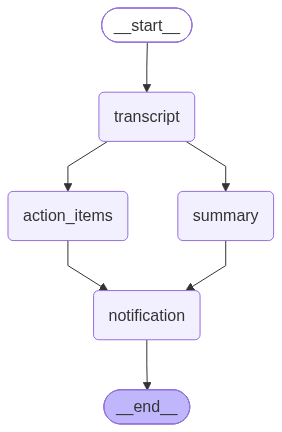

In [ ]:
# graph building
builder = StateGraph(MeetingState)

# adding nodes
builder.add_node('transcript',transcript_node)
builder.add_node('summary',summary_node)
builder.add_node('action_items',action_items)
builder.add_node('notification',notification_node)

# adding edges
builder.add_edge(START, "transcript")

builder.add_edge("transcript", "summary")
builder.add_edge("transcript", "action_items")

builder.add_edge("summary", "notification")
builder.add_edge("action_items", "notification")

builder.add_edge("notification", END)

graph = builder.compile()
graph


In [30]:
inital_state = {
    "video_path":"C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\\New folder\\videoplayback.mp4"
}

result = graph.invoke(inital_state)


 Meeting Processing Completed Successfully

Video:
C:\Users\SKharade\Projects and Learning\C_TEST_RECORDING\New folder\videoplayback.mp4

Generated Files:
✓ Transcript
✓ Summary
✓ Action Items




In [53]:
from watchdog.observers import Observer
from watchdog.events import FileSystemEventHandler
import time

WATCH_FOLDER = r"C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING"

class MyHandler(FileSystemEventHandler):

    def on_created(self, event):

        if event.is_directory:
            return

        print("New file:", event.src_path)

        # Trigger your LangGraph
        process_file(event.src_path)


def process_file(path):
    print("Running LangGraph for:", path)

    # graph.invoke(...)
    # pass file path to your graph


observer = Observer()
observer.schedule(MyHandler(), WATCH_FOLDER, recursive=False)
observer.start()

try:
    while True:
        time.sleep(1)

except KeyboardInterrupt:
    observer.stop()

observer.join()

New file: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
Running LangGraph for: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
New file: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
Running LangGraph for: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
New file: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
Running LangGraph for: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
New file: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
Running LangGraph for: C:\\Users\\SKharade\\Projects and Learning\\C_TEST_RECORDING\videoplayback.mp4
